# Amna Kauser 

# Task :2 Credit Risk Prediction

In [1]:
#importing libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn 
import sklearn as sk

In [2]:
loan=pd.read_csv('C:/Users/User/Downloads/archive (2)/Loan_default.csv')

In [16]:
loan.columns

Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
       'Default'],
      dtype='object')

In [19]:
loan.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


# Key Features Visualization

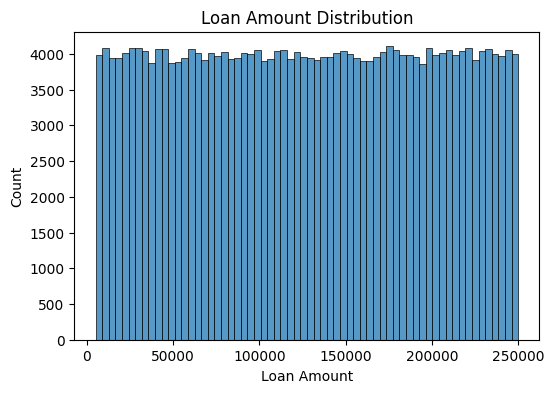

In [14]:
# 1. Loan Amount Distribution
plt.figure(figsize=(6,4))
sn.histplot(loan['LoanAmount'])
plt.title('Loan Amount Distribution')
plt.xlabel('Loan Amount')
plt.show()

The loan amounts are evenly distributed from $0 to $250,000 — every amount range has almost the same count of around 4,000 customers, meaning there is no particular loan amount that is more common than others. This looks like a uniformly distributed dataset. 

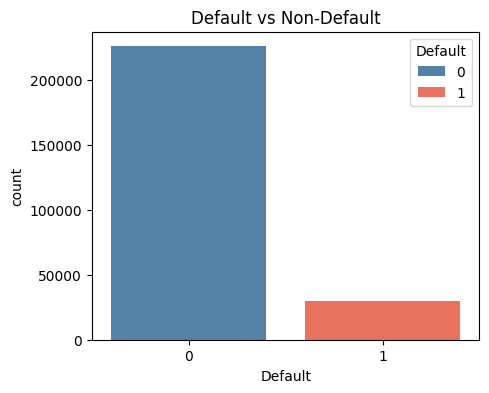

In [8]:
# 2. Default Count
plt.figure(figsize=(5,4))
sn.countplot(x='Default', data=loan,hue='Default', palette=['steelblue','tomato'])
plt.title('Default vs Non-Default')
plt.show()


The majority of customers (~225,000) are non-defaulters (0) who repaid their loans, while only a small group (~30,000) are defaulters (1) who failed to repay.
This means the dataset is imbalanced — defaulters are much fewer than non-defaulters, which can make it harder for the model to correctly predict defaults. 

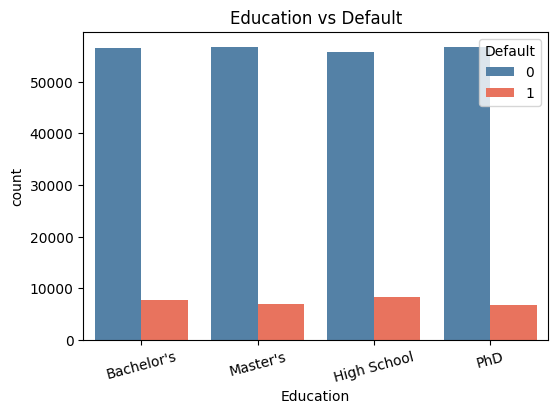

In [12]:
# 3. Education vs Default
plt.figure(figsize=(6,4))
sn.countplot(x='Education', hue='Default', data=loan, palette=['steelblue','tomato'])
plt.title('Education vs Default')
plt.xticks(rotation=15)
plt.show()

Education level has almost no effect on loan default — all four groups (Bachelor's, Master's, High School, PhD) have nearly the same count of defaulters (red) and non-defaulters (blue).
This means a customer's education level is not a useful predictor of whether they will default on their loan or not. 

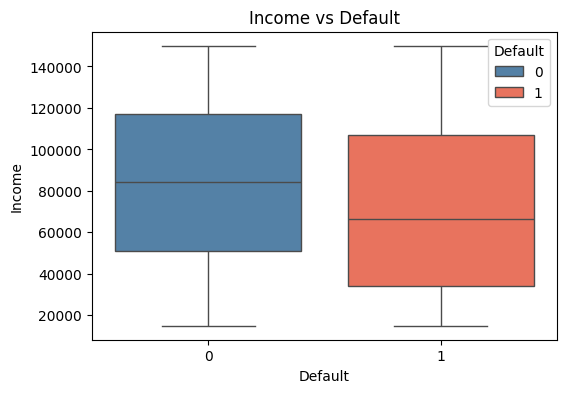

In [18]:
# 4. Income vs Default
plt.figure(figsize=(6,4))
sn.boxplot(x='Default', y='Income', hue='Default',data=loan, palette=['steelblue','tomato'])
plt.title('Income vs Default')
plt.show()

Non-defaulters (0) have a higher median income of around $85,000, while defaulters (1) have a lower median income of around $65,000, meaning lower income customers are more likely to default on their loan.
This shows that income is a useful predictor — the less a customer earns, the higher the risk of them not repaying the loan. 

# Decision Tree 

In [26]:
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Encode categorical columns
le = LabelEncoder()
loan['Education']      = le.fit_transform(loan['Education'])
loan['EmploymentType'] = le.fit_transform(loan['EmploymentType'])
loan['MaritalStatus']  = le.fit_transform(loan['MaritalStatus'])
loan['HasMortgage']    = le.fit_transform(loan['HasMortgage'])
loan['HasDependents']  = le.fit_transform(loan['HasDependents'])
loan['LoanPurpose']    = le.fit_transform(loan['LoanPurpose'])
loan['HasCoSigner']    = le.fit_transform(loan['HasCoSigner'])

# Features & Target
feature_cols = ['Age', 'Income', 'LoanAmount', 'CreditScore',
                'MonthsEmployed', 'InterestRate', 'DTIRatio',
                'Education', 'EmploymentType']
X = loan[feature_cols]
y = loan['Default']

# Split ONCE only
X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=1)

# Train
clf = DecisionTreeClassifier(criterion="entropy", max_depth=3)
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))



Accuracy: 0.8848116963644671


# Accuracy and a confusion matrix.

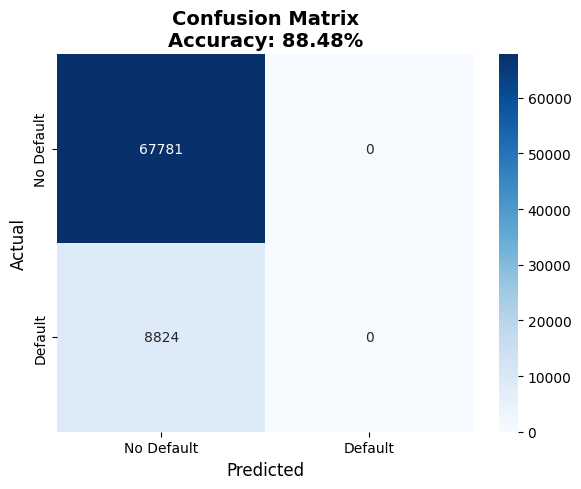

Accuracy: 88.48 %


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default','Default'],
            yticklabels=['No Default','Default'])

plt.title(f'Confusion Matrix\nAccuracy: {acc:.2%}', fontsize=14, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()

print("Accuracy:", round(acc*100, 2), "%")

The model has 88.48% accuracy but there is a serious problem here:
The model predicted "No Default" for every single customer — it correctly identified 67,781 non-defaulters but completely missed all 8,824 actual defaulters (bottom right shows 0).
This is the imbalanced dataset problem we saw earlier — since 88% of customers are non-defaulters, the model just always predicts "No Default" and still gets high accuracy, but it's actually a bad model because it can never detect who will actually default.